# **KHÁM PHÁ DỮ LIỆU (EDA)**

**Dataset:** IBM.csv  
**Mục tiêu**: Hiểu cấu trúc dữ liệu, phân bố biến, phát hiện outlier và các đặc trưng liên quan đến Attrition  
**Biến mục tiêu:** `Attrition` - nhân viên có nghỉ việc hay không (`Yes` / `No`)

***
## **Mô tả dữ liệu**

| Cột | Kiểu | Ý nghĩa |
|---|---|---|
| `Age` | Số | Tuổi nhân viên |
| `Attrition` | Phân loại | **Biến mục tiêu** - nghỉ việc (Yes) hay ở lại (No) |
| `Department` | Phân loại | Phòng ban |
| `DistanceFromHome` | Số | Khoảng cách từ nhà đến nơi làm (km) |
| `Education` | Thứ tự (1-5) | Trình độ học vấn (1=Below College, 2=College, 3=Bachelor, 4=Master, 5=Doctor) |
| `EducationField` | Phân loại | Lĩnh vực học vấn |
| `EnvironmentSatisfaction` | Thứ tự (1-4) | Mức độ hài lòng môi trường làm việc |
| `JobSatisfaction` | Thứ tự | Mức độ hài lòng công việc |
| `MaritalStatus` | Phân loại | Tình trạng hôn nhân |
| `MonthlyIncome` | Số | Thu nhập hàng tháng (USD) |
| `NumCompaniesWorked` | Số | Số công ty từng làm |
| `WorkLifeBalance` | Thứ tự (1–4) | Mức độ cân bằng công việc–cuộc sống |
| `YearsAtCompany` | Số | Số năm gắn bó với công ty |

## **0. Cài đặt các thư viện và thiết lập cấu hình**

In [173]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [174]:
import warnings
warnings.filterwarnings("ignore")

In [175]:
sns.set_theme(style="whitegrid", palette="Set2")

DATA_PATH = "../data/IBM.csv"
FIGURES_DIR = "../outputs/figures_eda"

os.makedirs(FIGURES_DIR, exist_ok=True)

## **1. Đọc và tổng quan dữ liệu**

In [176]:
df = pd.read_csv(DATA_PATH)
df

,Age,Attrition,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany
0,41,Yes,Sales,1,2,Life Sciences,2,4,Single,5993,8,1,6
1,49,No,Research & Development,8,1,Life Sciences,3,2,Married,5130,1,3,10
2,37,Yes,Research & Development,2,2,Other,4,3,Single,2090,6,3,0
3,33,No,Research & Development,3,4,Life Sciences,4,3,Married,2909,1,3,8
4,27,No,Research & Development,2,1,Medical,1,2,Married,3468,9,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Research & Development,23,2,Medical,3,4,Married,2571,4,3,5
1466,39,No,Research & Development,6,1,Medical,4,1,Married,9991,4,3,7
1467,27,No,Research & Development,4,3,Life Sciences,2,2,Married,6142,1,3,6
1468,49,No,Sales,2,3,Medical,4,2,Married,5390,2,2,9


In [177]:
# Làm sạch tên cột để tránh các trường hợp dư dấu cách ở tên cột
df.columns = df.columns.str.strip()

In [178]:
# Làm sạch dữ liệu dạng chữ trong bảng
for col in df.select_dtypes("object").columns:
    df[col] = df[col].str.strip()

In [179]:
print(f"Kích thước: {df.shape[0]} dòng x {df.shape[1]} cột")
df.head()

Kích thước: 1470 dòng x 13 cột


,Age,Attrition,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany
0,41,Yes,Sales,1,2,Life Sciences,2,4,Single,5993,8,1,6
1,49,No,Research & Development,8,1,Life Sciences,3,2,Married,5130,1,3,10
2,37,Yes,Research & Development,2,2,Other,4,3,Single,2090,6,3,0
3,33,No,Research & Development,3,4,Life Sciences,4,3,Married,2909,1,3,8
4,27,No,Research & Development,2,1,Medical,1,2,Married,3468,9,3,2


In [180]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Age                      1470 non-null   int64
 1   Attrition                1470 non-null   str  
 2   Department               1470 non-null   str  
 3   DistanceFromHome         1470 non-null   int64
 4   Education                1470 non-null   int64
 5   EducationField           1470 non-null   str  
 6   EnvironmentSatisfaction  1470 non-null   int64
 7   JobSatisfaction          1470 non-null   int64
 8   MaritalStatus            1470 non-null   str  
 9   MonthlyIncome            1470 non-null   int64
 10  NumCompaniesWorked       1470 non-null   int64
 11  WorkLifeBalance          1470 non-null   int64
 12  YearsAtCompany           1470 non-null   int64
dtypes: int64(9), str(4)
memory usage: 149.4 KB


In [181]:
print("== Kiểu dữ liệu ==")
print(df.dtypes)
print(f"\nGiá trị thiếu:\n{df.isnull().sum()}")
print(f"\nSố dòng trùng lặp: {df.duplicated().sum()}")

== Kiểu dữ liệu ==
Age                        int64
Attrition                    str
Department                   str
DistanceFromHome           int64
Education                  int64
EducationField               str
EnvironmentSatisfaction    int64
JobSatisfaction            int64
MaritalStatus                str
MonthlyIncome              int64
NumCompaniesWorked         int64
WorkLifeBalance            int64
YearsAtCompany             int64
dtype: object

Giá trị thiếu:
Age                        0
Attrition                  0
Department                 0
DistanceFromHome           0
Education                  0
EducationField             0
EnvironmentSatisfaction    0
JobSatisfaction            0
MaritalStatus              0
MonthlyIncome              0
NumCompaniesWorked         0
WorkLifeBalance            0
YearsAtCompany             0
dtype: int64

Số dòng trùng lặp: 0


In [182]:
# Loại các cột không có giá trị biến thiên
low_variance_cols = [col for col in df.columns if df[col].nunique() <= 1]
if low_variance_cols:
    df = df.drop(columns=low_variance_cols)
    print(f"Đã loại cột không biến thiên: {low_variance_cols}")
else:
    print("Không có cột nào cần loại.")

print(f"Kích thước sau làm sạch: {df.shape[0]} dòng x {df.shape[1]} cột")

Không có cột nào cần loại.
Kích thước sau làm sạch: 1470 dòng x 13 cột


In [183]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.0,60.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.0,3.0,4.0,4.0
JobSatisfaction,1470.0,2.728571,1.102846,1.0,2.0,3.0,4.0,4.0
MonthlyIncome,1470.0,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.0,19999.0
NumCompaniesWorked,1470.0,2.693197,2.498009,0.0,1.0,2.0,4.0,9.0
WorkLifeBalance,1470.0,2.761224,0.706476,1.0,2.0,3.0,3.0,4.0
YearsAtCompany,1470.0,7.008163,6.126525,0.0,3.0,5.0,9.0,40.0


## **2. Phân loại biến**

In [184]:
target = "Attrition"
all_numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.drop(columns=["Attrition"]).select_dtypes(include=["object", "category"]).columns.tolist()

# Đặt ngưỡng threshold để tách biến liên tục và biến thứ tự
# Nếu một cột số có từ 6 giá trị duy nhất trở xuống => biến thứ tự (ordinal)
THRESHOLD = 6

continuous_cols = []
ordinal_cols = []

for col in all_numeric_cols:
    # Bỏ qua cột Attrition nếu nằm trong danh sách cột số
    if col == "Attrition": 
        continue

    unique_count = df[col].nunique()
    
    if unique_count <= THRESHOLD:
        ordinal_cols.append(col)
    else:
        continuous_cols.append(col)

print(f"Biến mục tiêu: {target}\n")
print(f"Số biến số liên tục ({len(continuous_cols)} cột): {continuous_cols}\n")
print(f"Số biến có thứ tự ({len(ordinal_cols)} cột): {ordinal_cols}\n")
print(f"Số biến chữ phân loại ({len(cat_cols)} cột): {cat_cols}")

Biến mục tiêu: Attrition

Số biến số liên tục (5 cột): ['Age', 'DistanceFromHome', 'MonthlyIncome', 'NumCompaniesWorked', 'YearsAtCompany']

Số biến có thứ tự (4 cột): ['Education', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance']

Số biến chữ phân loại (3 cột): ['Department', 'EducationField', 'MaritalStatus']


## **3. Phân tích biến mục tiêu - Attrition**

In [185]:
counts = df[target].value_counts()
percent = df[target].value_counts(normalize=True) * 100
percent

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

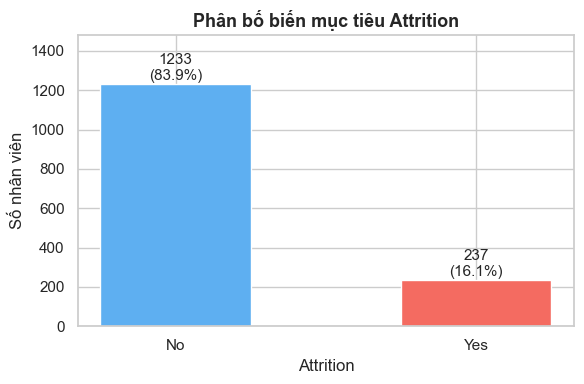

In [186]:
fig, ax = plt.subplots(figsize=(6, 4))
colors = ["#5EAFF1", "#F46B61"]
bars = ax.bar(counts.index, counts.values, color=colors, width=0.5, edgecolor="white")
for bar, val, per in zip(bars, counts.values, percent.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        f"{val}\n({per:.1f}%)",
        ha="center", fontsize=11
    )
ax.set_title("Phân bố biến mục tiêu Attrition", fontsize=13, fontweight="bold")
ax.set_ylim(0, counts.max()*1.2)
ax.set_xlabel("Attrition")
ax.set_ylabel("Số nhân viên")
plt.tight_layout()    
plt.savefig(f"{FIGURES_DIR}/eda_01_target_distribution.png", dpi=150)
plt.show()

***Nhận xét:***
- Tập dữ liệu có 1470 nhân viên, trong đó chỉ có 237 người nghỉ việc (16.1%) và 1233 người ở lại (83.9%)

- Dữ liệu bị mất cân bằng lớp (~1:5). Nếu đánh giá mô hình chỉ bằng Accuracy sẽ chưa hoàn toàn chính xác, sẽ cần phải dùng thêm chỉ số Precision, Recall, F1-score

- Khi huấn luyện mô hình cần dùng `class_weight=balanced` hoặc `stratify=y` khi chia train/test

## **4. Phân tích biến số liên tục (continuous features)**

Phân tích biến số liên tục trong mối quan hệ với nhãn "Yes" của biến mục tiêu Attrition

In [187]:
# Các biến số liên tục
continuous_cols

['Age',
 'DistanceFromHome',
 'MonthlyIncome',
 'NumCompaniesWorked',
 'YearsAtCompany']

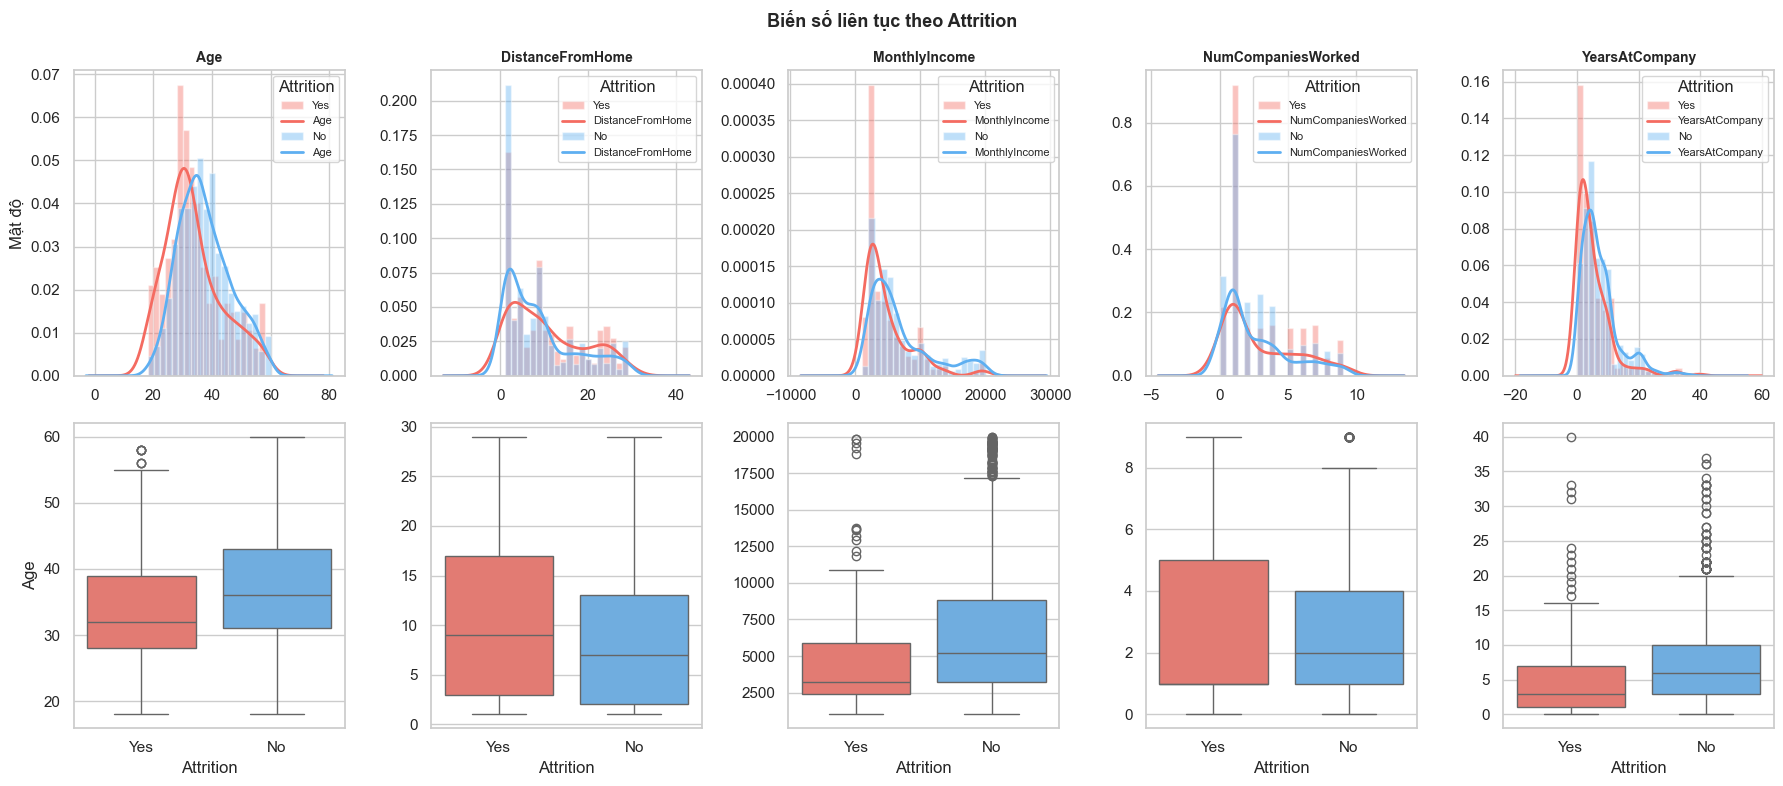

In [188]:
palette = {"Yes": "#F46B61", "No": "#5EAFF1"}

fig, axes = plt.subplots(2, len(continuous_cols), figsize=(18, 8))

for i, col in enumerate(continuous_cols):
    # KDE plot
    for group, color in palette.items():
        subset = df[df["Attrition"] == group][col]
        axes[0, i].hist(subset, bins=20, alpha=0.4, color=color, label=group, density=True)
        subset.plot.kde(ax=axes[0, i], color=color, linewidth=2)
    axes[0, i].set_title(col, fontsize=10, fontweight="bold")
    axes[0, i].set_ylabel("Mật độ" if i == 0 else "")
    axes[0, i].legend(title="Attrition", fontsize=8)

    # Boxplot
    sns.boxplot(
        data=df,
        x="Attrition",
        y=col,
        hue="Attrition",
        palette=palette,
        ax=axes[1, i],
        legend=False
    )
    axes[1, i].set_xlabel("Attrition")
    axes[1, i].set_ylabel(col if i == 0 else "")

fig.suptitle("Biến số liên tục theo Attrition", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/eda_02_continuous_features.png", dpi=150)
plt.show()

***Nhận xét:***
- Age: Nhân viên nghỉ việc (`Yes`) có xu hướng trẻ hơn, phân bố lệch về nhóm 25-35 tuổi

- MonthlyIncome: Nhóm nghỉ việc có thu nhập thấp hơn rõ rệt, đây là đặc trưng phân biệt mạnh

- YearsAtCompany: Nhóm nghỉ việc có số năm gắn bó với công ty ít hơn, tập trung ở 0-5 năm đầu

- DistanceFromHome: Nhóm nghỉ việc có khoảng cách xa hơn nhưng sự khác biệt không lớn

- NumCompaniesWorked: Phân bố tương đối giống nhau giữa 2 nhóm, ít phân biệt

## **5. Phân tích biến có thứ tự (ordinal features)**

Phân tích biến có thứ tự trong mối quan hệ với nhãn "Yes" của biến mục tiêu Attrition

In [189]:
ordinal_cols

['Education', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance']

In [190]:
# Chuyển thành dictionary
ordinal_cols = [
    ("Education",                "Trình độ học vấn (1-5)"),
    ("EnvironmentSatisfaction",  "Hài lòng môi trường (1-4)"),
    ("JobSatisfaction",          "Hài lòng công việc (1-4)"),
    ("WorkLifeBalance",          "Cân bằng công việc và cuộc sống (1-4)")
]

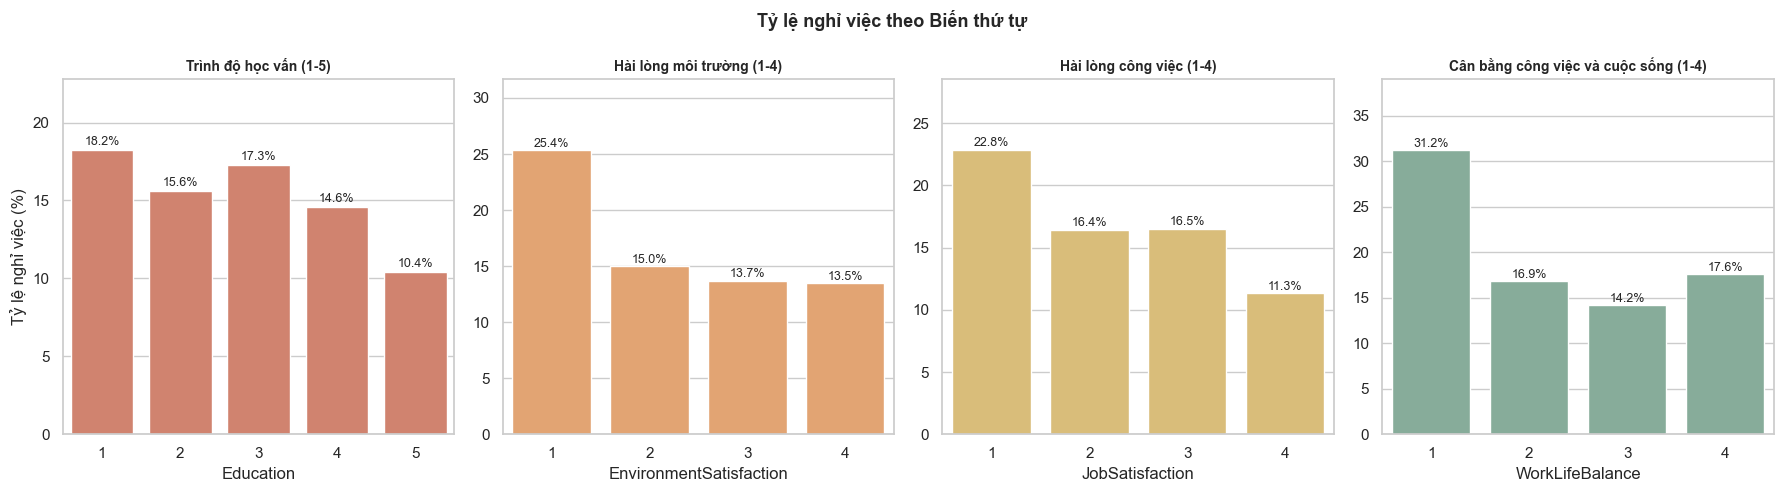

In [191]:
fig, axes = plt.subplots(1, len(ordinal_cols), figsize=(18, 5))
colors = ["#E07A5F", "#F4A261", "#E9C46A", "#81B29A"]

for i, (col, label) in enumerate(ordinal_cols):
    # Tính tỷ lệ nghỉ việc theo từng mức
    rate = (
        df.groupby(col)["Attrition"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .reset_index()
    )
    rate.columns = [col, "AttritionRate"]

    sns.barplot(
        data=rate, x=col, y="AttritionRate",
        color=colors[i], ax=axes[i]
    )
    # Ghi số % lên mỗi cột
    for bar in axes[i].patches:
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f"{bar.get_height():.1f}%",
            ha="center", fontsize=9
        )
    axes[i].set_title(label, fontsize=10, fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Tỷ lệ nghỉ việc (%)" if i == 0 else "")
    axes[i].set_ylim(0, rate["AttritionRate"].max() * 1.25)

fig.suptitle("Tỷ lệ nghỉ việc theo Biến thứ tự", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/eda_03_ordinal_features.png", dpi=150)
plt.show()

**Nhận xét:**
- JobSatisfaction: Mức 1 (thấp nhất) có tỷ lệ nghỉ cao nhất.

- EnvironmentSatisfaction: Mức hài lòng thấp đi kèm tỷ lệ nghỉ cao hơn.

- WorkLifeBalance: Mức 1 (tệ nhất) nghỉ việc nhiều nhất, nhưng mức 2–4 không chênh lệch nhiều.

- Education: Không có xu hướng tuyến tính rõ => trình độ học vấn ít ảnh hưởng trực tiếp đến Attrition.

> Dùng **tỷ lệ %** thay vì count là quan trọng ở đây vì số nhân viên ở mỗi mức không bằng nhau.

## **5. Phân tích biến phân loại (categorial features)**

In [192]:
cat_cols

['Department', 'EducationField', 'MaritalStatus']

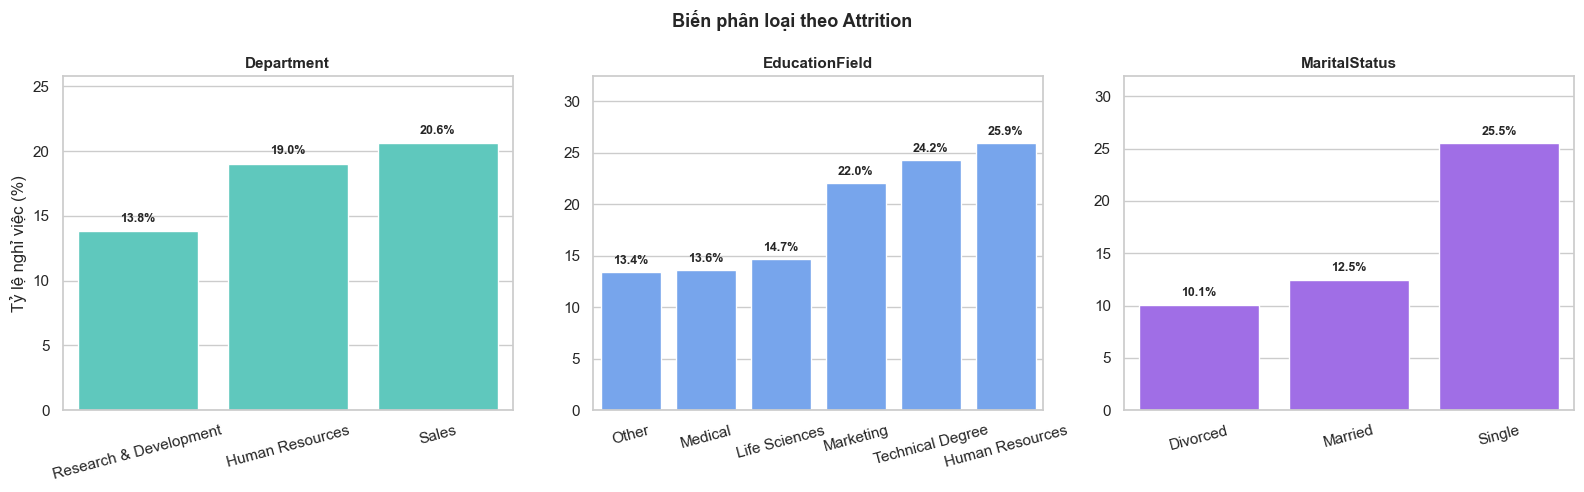

In [193]:
colors = ["#4ED9CB", "#64A1FF", "#9D5AFA"]

fig, axes = plt.subplots(1, len(cat_cols), figsize=(16, 5))

for i, col in enumerate(cat_cols):
    # Tính tỷ lệ phần trăm nghỉ việc 
    cat_rate = (
        df.groupby(col)["Attrition"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=True) 
        .reset_index()
    )
    cat_rate.columns = [col, "AttritionRate"]

    
    sns.barplot(
        data=cat_rate, x=col, y="AttritionRate",
        color=colors[i], ax=axes[i]  
    )
    
    
    for p in axes[i].patches:
        axes[i].text(
            p.get_x() + p.get_width() / 2,
            p.get_height() + 0.5,  
            f"{p.get_height():.1f}%",
            ha="center", va="bottom", fontsize=9, fontweight="bold"
        )

    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Tỷ lệ nghỉ việc (%)" if i == 0 else "") 
    axes[i].tick_params(axis="x", rotation=15)
    
    # Nới rộng chiều cao trục Y lên một chút để chừa khoảng trống không bị che mất chữ %
    axes[i].set_ylim(0, cat_rate["AttritionRate"].max() * 1.25)

fig.suptitle("Biến phân loại theo Attrition", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/eda_04_categorical.png", dpi=150)
plt.show()

***Nhận xét***
- Development: phòng Sales có tỷ lệ nghỉ cao hơn R&D và HR

- EducationField: Human Resources và Technical Degree có tỉ lệ nghỉ cao hơn các ngành khác

- MaritalStatus: Nhân viên độc thân (single) nghỉ việc nhiều nhất, có thể do ít ràng buộc hơn về tài chính gia đình

## **6. Phân tích Outliers**

- Biến 'Age': Phát hiện 0 dòng outliers (0.0%)
- Biến 'DistanceFromHome': Phát hiện 0 dòng outliers (0.0%)
- Biến 'MonthlyIncome': Phát hiện 114 dòng outliers (7.8%)
- Biến 'NumCompaniesWorked': Phát hiện 52 dòng outliers (3.5%)
- Biến 'YearsAtCompany': Phát hiện 104 dòng outliers (7.1%)


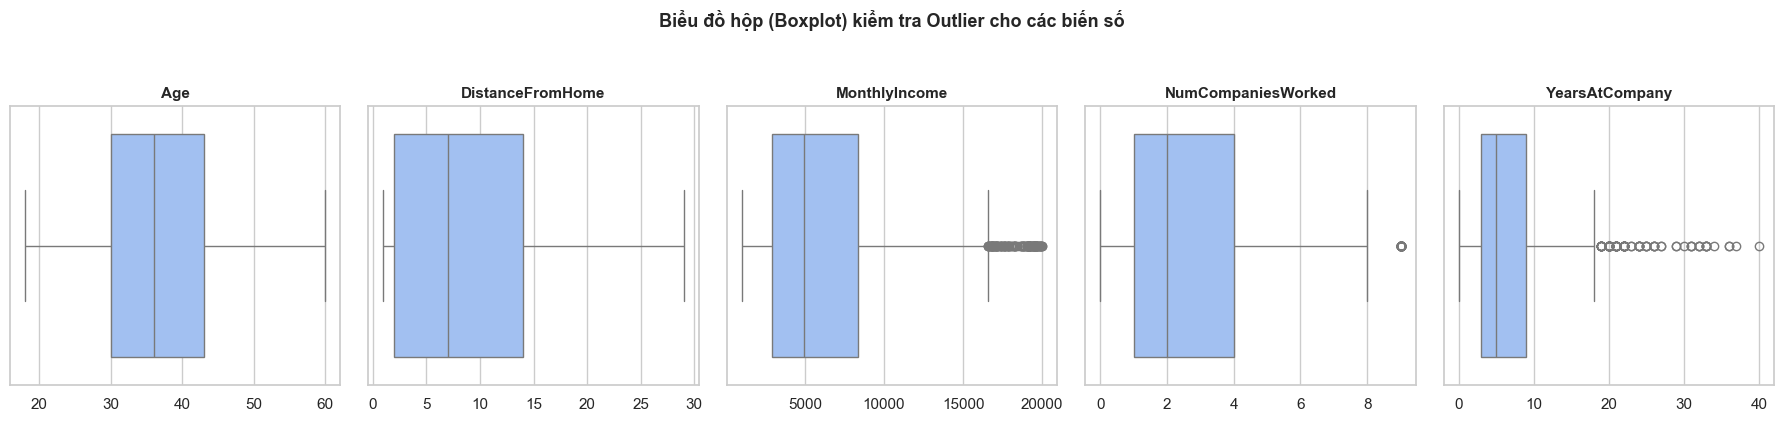

In [194]:
fig, axes = plt.subplots(1, len(continuous_cols), figsize=(18, 4))

for i, col in enumerate(continuous_cols):
    if col in df.columns:
        # 1. Vẽ Boxplot
        sns.boxplot(data=df, x=col, color="#95BDFE", ax=axes[i])
        axes[i].set_title(col, fontsize=11, fontweight="bold")
        axes[i].set_xlabel("")
        
        # 2. Tính toán số lượng outlier 
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Đếm số dòng nằm ngoài ranh giới [lower_bound, upper_bound]
        num_outliers = len(df[(df[col] < lower_bound) | (df[col] > upper_bound)])
        percentage = (num_outliers / len(df)) * 100
        
        print(f"- Biến '{col}': Phát hiện {num_outliers} dòng outliers ({percentage:.1f}%)")
    else:
        print(f"- Cột '{col}' không tồn tại trong dataframe.")

fig.suptitle("Biểu đồ hộp (Boxplot) kiểm tra Outlier cho các biến số", fontsize=13, fontweight="bold", y=1.05)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/eda_05_outliers_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

***Nhận xét:***

- `Age` và `DistanceFromHome` không có outlier.

- `MonthlyIncome` xuất hiện một dải dày đặc các outliers ở phía bên phải (vượt ngưỡng khoảng 16,500 USD), cho thấy trong công ty có một nhóm nhỏ nhân sự nhận mức lương cao vượt trội so với đại đa số nhân viên thông thường (phù hợp với thực tế cơ cấu quản lý/cấp cao).

- `YearsAtCompany` có khá nhiều outliers kéo dài từ mốc 20 năm đến 40 năm. Đây là nhóm nhân viên có thâm niên cống hiến đặc biệt dài so với phân bố chung (vốn tập trung ở mức dưới 10 năm).

=> Các outliers phát hiện được ở biến `MonthlyIncome` và `YearsAtCompany` phản ánh đúng thực tế tự nhiên của cơ cấu nhân sự doanh nghiệp (nhóm quản lý lương cao, nhóm nhân viên trung thành lâu năm), không phải do lỗi nhập liệu. Do đó, các outlier này sẽ được giữ nguyên để bảo toàn thông tin chi tiết của tập dữ liệu.

## **7. Ma trận tương quan (correlation analysis)**

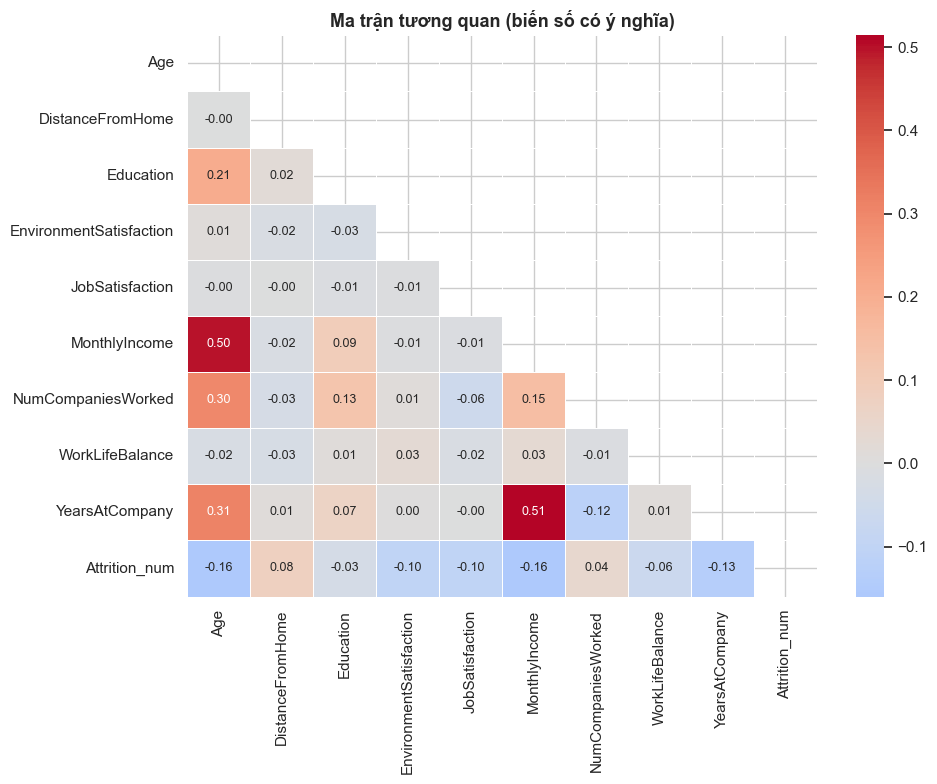

In [195]:
# Encode Attrition để tính tương quan
df["Attrition_num"] = (df["Attrition"] == "Yes").astype(int)

# Lấy các biến số có ý nghĩa
numeric_cols = [
    "Age", "DistanceFromHome", "Education",
    "EnvironmentSatisfaction", "JobSatisfaction",
    "MonthlyIncome", "NumCompaniesWorked",
    "WorkLifeBalance", "YearsAtCompany", "Attrition_num"
]

# Tính hệ số tương quan
corr = df[numeric_cols].corr()

# Trực quan
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask,
    annot=True, fmt=".2f", cmap="coolwarm",
    center=0, linewidths=0.5, ax=ax,
    annot_kws={"size": 9}
)
ax.set_title("Ma trận tương quan (biến số có ý nghĩa)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/eda_06_correlation_heatmap.png", dpi=150)
plt.show()

***Nhận xét:***  
Với biến mục tiêu Attrition:

- `MonthlyIncome` (-0.16) và `Age` (-0.16): Đây là hai biến có tương quan nghịch mạnh nhất với nghỉ việc (Attrition). Nhân viên càng trẻ tuổi và thu nhập càng thấp thì tỷ lệ nghỉ việc càng cao. Ngược lại, người lớn tuổi, lương cao sẽ ít nghỉ việc hơn.

- YearsAtCompany (-0.13): Tương quan nghịch. Nhân viên mới có nguy cơ rời đi cao hơn những người đã làm việc lâu năm.

- `EnvironmentSatisfaction` (-0.10) và `JobSatisfaction` (-0.10): Tương quan nghịch. Mức độ hài lòng với môi trường và công việc càng thấp (điểm 1, 2) thì tỷ lệ nghỉ việc càng tăng. Có thể sự bất mãn về môi trường và bản chất công việc là động cơ thúc đẩy nhân viên nghỉ việc.

- `DistanceFromHome` (+0.08): Biến duy nhất có tương quan thuận. Có thể nhà càng xa công ty thì nguy cơ nghỉ việc càng có xu hướng tăng nhẹ.

Các cặp biến có tương quan thuận mạnh, thể hiện mối quan hệ logic phù hợp với thực tế:
- `MonthlyIncome` (Thu nhập) và `YearsAtCompan`y (Số năm làm việc): 0.51 => Người làm việc ở công ty càng lâu năm thì thu nhập của họ càng cao.

- `MonthlyIncome` (Thu nhập) và `Age` (Tuổi): 0.50 => Người lớn tuổi hơn thường có vị trí cao hơn và nhận lương cao hơn.

- `YearsAtCompany` (Số năm làm việc) và `Age` (Tuổi): 0.31 => Nhân viên lớn tuổi thường có xu hướng gắn bó số năm lâu hơn.

- `NumCompaniesWorked` (Số công ty từng làm) và `Age` (Tuổi): 0.30 => Càng nhiều tuổi thì số lượng công ty họ từng nhảy việc qua trong quá khứ càng nhiều.

**Sự tương quan giữa các đặc trung với Attrition**

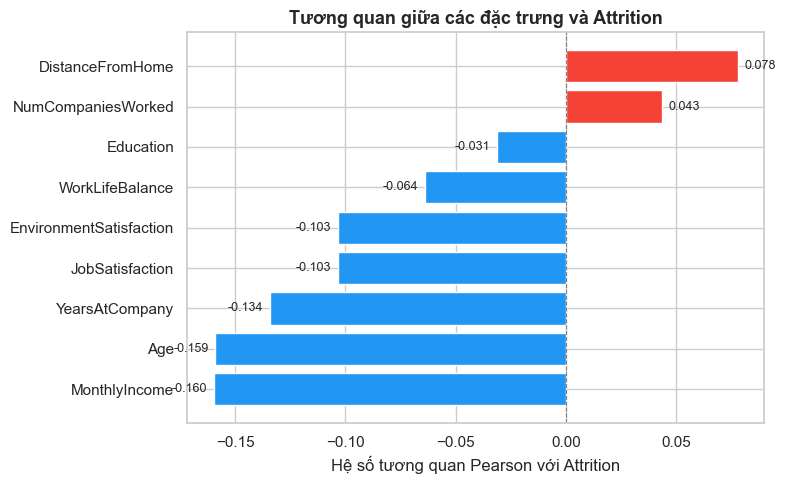

In [196]:
target_corr = (
    corr["Attrition_num"]
    .drop("Attrition_num")
    .sort_values()
)

colors = ["#F44336" if v > 0 else "#2196F3" for v in target_corr.values]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor="white")
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
for bar in bars:
    w = bar.get_width()
    ax.text(
        w + (0.003 if w >= 0 else -0.003),
        bar.get_y() + bar.get_height() / 2,
        f"{w:.3f}",
        va="center",
        ha="left" if w >= 0 else "right",
        fontsize=9
    )
ax.set_xlabel("Hệ số tương quan Pearson với Attrition")
ax.set_title("Tương quan giữa các đặc trưng và Attrition", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/eda_07_correlation_with_target.png", dpi=150)
plt.show()

**Nhận xét:**
- Màu đỏ = tương quan dương với Attrition (giá trị cao => nghỉ nhiều hơn).

- Màu xanh = tương quan âm với Attrition (giá trị cao => ở lại nhiều hơn).

- MonthlyIncome, Age, YearsAtCompany có tương quan âm mạnh nhất - thu nhập cao, tuổi lớn, gắn bó lâu => ít nghỉ hơn.

- DistanceFromHome, NumCompaniesWorked có tương quan dương - xa nhà, nhảy việc nhiều => xu hướng nghỉ cao hơn.

## **8. Tổng kết**

- Mất cân bằng lớp nghiêm trọng: 16.1% Yes - cần `class_weight='balanced'` hoặc SMOTE.

- Không có giá trị thiếu hoặc trùng lặp => dữ liệu sạch.

- Biến quan trọng: `MonthlyIncome`, `Age`, `YearsAtCompany`, `JobSatisfaction`, `EnvironmentSatisfaction`, `DistanceFromHome` có phân bố khác biệt rõ giữa 2 nhóm.

- Phòng Sales có tỷ lệ nghỉ cao nhất; nhân viên độc thân (Single) nghỉ nhiều hơn.

- Biến phân loại (`Department`, `MaritalStatus`, `EducationField`) cần mã hóa bằng `OneHotEncoder`.

- Biến thứ tự (`JobSatisfaction`, `WorkLifeBalance`, `Education`) có thể giữ nguyên dạng số hoặc encode thứ tự.

- Không cần loại cột trong dataset 13 cột này vì tất cả đều có biến thiên.